# Figure 5 — HRD timing analysis

Every panel is derived from a single results table (Table S2, `HRDTimer Estimates`), which merges four breast-cancer cohorts (INFORM, SCANB, PCAWG, GEL). `age_at_diagnosis` is the age at diagnosis in years. **GEL:** exact age and calendar HRD-onset age are not disclosed and are omitted from Table S2 — for GEL we reconstruct age here as the **5-year age-band midpoint**, and HRD onset age simply as **band midpoint − HRD duration** (Table S2 stores only the band and the duration in years).

**Panels**
1. HRD onset lollipop (sorted by cohort + subtype)
2. HRD Duration — Gradual vs Two-Step vs HRDTime
3. TP53 mutation status vs HRD Duration
4. HRD metrics by HRD origin — Duration / HRDTime / Age
5. Ridge regression — predictors of 1−HRDTime and HRD Duration
6. Sensitivity — ridge + T-stage

In [1]:
from __future__ import annotations
import os, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.utils import resample
from itertools import combinations

from hrdtimer.age_model_plots import plot_hrd_onset

%matplotlib inline

In [2]:
# ── Paths ───────────────────────────────────────────
RESULTS_XLSX = "../supplemental_tables_v2/SupTable8_HRDTimer_estimates.xlsx"
S2_INV = {"sample_id": "sample", "subtype": "type", "is_WGD": "isWGD", "tumour_grade": "grade", "clinical_stage": "final_stage_main", "hrd_origin": "hrd.origin", "hrd_origin_with_methylation": "hrd.origin.with.meth", "HRD_genotype": "genotype", "CHORD_genotype": "chord.genotype", "TP53_mutated": "isTp53Mut", "PALB2_mutated": "isPALB2Mut", "HRDetect_score": "HRDetect", "is_HRD": "HRDetect.isHRD", "T_stage": "T_STAGE", "tumour_size_mm": "tum.size.mm", "age_band_label": "age_band", "BRCA1_monoallelic": "isBRCA1Monoallelic", "BRCA1_biallelic": "isBRCA1Biallelic", "BRCA2_monoallelic": "isBRCA2Monoallelic", "BRCA2_biallelic": "isBRCA2Biallelic", "BRCA1_promoter_methylation_class": "BRCA1_PromMetClass", "RAD51C_promoter_methylation_class": "RAD51C_PromMetClass", "HRDTime_molecular": "HRDTime", "HRDTime_molecular_ci_lo": "HRDTime_ci_lo", "HRDTime_molecular_ci_hi": "HRDTime_ci_hi", "HRDTime_molecular_IQR_lo": "HRDTime_ci_IQR_lo", "HRDTime_molecular_IQR_hi": "HRDTime_ci_IQR_hi", "WGDTime_molecular": "WGDTime", "WGDTime_molecular_ci_lo": "WGDTime_ci_lo", "WGDTime_molecular_ci_hi": "WGDTime_ci_hi", "WGDTime_molecular_IQR_lo": "WGDTime_ci_IQR_lo", "WGDTime_molecular_IQR_hi": "WGDTime_ci_IQR_hi", "HRD_duration_median_yrs": "HRD_Duration_median", "HRD_duration_ci05_yrs": "HRD_Duration_ci05", "HRD_duration_ci95_yrs": "HRD_Duration_ci95", "TS_duration_median_yrs": "TS_Duration_median", "TS_duration_ci05_yrs": "TS_Duration_ci05", "TS_duration_ci95_yrs": "TS_Duration_ci95", "HRD_onset_age_median": "HRD_crossing_age_median", "HRD_onset_age_ci05": "HRD_crossing_age_ci05", "HRD_onset_age_ci95": "HRD_crossing_age_ci95", "TS_onset_age_median": "TS_crossing_age_median", "TS_onset_age_ci05": "TS_crossing_age_ci05", "TS_onset_age_ci95": "TS_crossing_age_ci95"}
OUTPUT_DIR   = "../output/Fig5_clean_v3"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Ordering & colours ───────────────────────────────────
COHORT_ORDER  = ["INFORM", "SCANB", "PCAWG", "GEL"]
TYPE_ORDER    = ["ER+", "TN"]
COHORT_COLORS = dict(zip(COHORT_ORDER, ["#2A9D8F", "#E9C46A", "#F4A261", "#264653"]))

BOX_PROPS = dict(
    boxprops     = dict(edgecolor="black", linewidth=0.25),
    whiskerprops = dict(color="black", linewidth=0.25),
    capprops     = dict(color="black", linewidth=0.25),
    medianprops  = dict(color="black", linewidth=1.5),
    flierprops   = dict(marker="o", markersize=2, markerfacecolor="lightgrey",
                        markeredgecolor="k", markeredgewidth=0.25),
)
SPINE_LW = 0.25
stars = lambda p: ("" if (isinstance(p, float) and np.isnan(p)) else
                   "***" if p < 1e-3 else "**" if p < 1e-2 else "*" if p < 0.05 else "ns")

def set_mpl_style():
    mpl.rcParams.update({
        "pdf.fonttype": 42, "ps.fonttype": 42,
        "font.family": "Sans", "font.size": 8,
        "text.color": "black", "axes.labelcolor": "black",
        "axes.spines.top": False, "axes.spines.right": False,
        "axes.linewidth": 0.5, "axes.edgecolor": "black",
        "xtick.color": "black", "ytick.color": "black",
        "xtick.direction": "out", "ytick.direction": "out",
        "xtick.major.width": 0.5, "ytick.major.width": 0.5,
        "xtick.labelsize": 8, "ytick.labelsize": 8,
        "figure.dpi": 600,
    })
set_mpl_style()

## Load the results table (Table S2)

In [3]:
df = pd.read_excel(RESULTS_XLSX, sheet_name="HRDTimer Estimates").rename(columns=S2_INV)
df = df[df["scaled_SBS1"].notna()].reset_index(drop=True)   # SBS1-timing cohort (matches v3)

# Normalise dtypes used downstream
df["type"] = df["type"].replace({"ER+HER2-": "ER+", "TNBC": "TN"}).fillna("other/unknown")
df["isTp53Mut"] = df["isTp53Mut"].map(lambda x: bool(x) if pd.notna(x) else np.nan)

print(f"Samples: {len(df)}")
print(df.groupby("cohort")["type"].value_counts(dropna=False).to_string())

# ── GEL: reconstruct calendar age downstream (NOT stored in Table S2) ──────
# GEL's approved export discloses only 5-year age bands, so exact age at diagnosis
# and calendar HRD-onset ages are omitted from Table S2 (only HRD duration in years
# is reported there). We reconstruct the band midpoint here for plotting/regression;
# onset age then follows as (age - duration).
import re as _re
def _band_mid(b):
    m = _re.findall(r"\d+", str(b))
    return (int(m[0]) + int(m[1])) / 2 if len(m) >= 2 else np.nan
_gel = df["cohort"].eq("GEL")
df.loc[_gel, "age_at_diagnosis"] = df.loc[_gel, "age_band"].map(_band_mid)
for _b in ("HRD", "TS"):
    df.loc[_gel, f"{_b}_crossing_age_median"] = df.loc[_gel, "age_at_diagnosis"] - df.loc[_gel, f"{_b}_Duration_median"]
    df.loc[_gel, f"{_b}_crossing_age_ci05"]   = df.loc[_gel, "age_at_diagnosis"] - df.loc[_gel, f"{_b}_Duration_ci95"]
    df.loc[_gel, f"{_b}_crossing_age_ci95"]   = df.loc[_gel, "age_at_diagnosis"] - df.loc[_gel, f"{_b}_Duration_ci05"]


Samples: 115
cohort  type         
GEL     other/unknown    25
        TN               15
        ER+              13
        HER2+             3
INFORM  TN                4
        ER+               2
PCAWG   TN               11
        ER+               9
SCANB   TN               33


## Fig 1 — HRD onset vs age at diagnosis (lollipop)

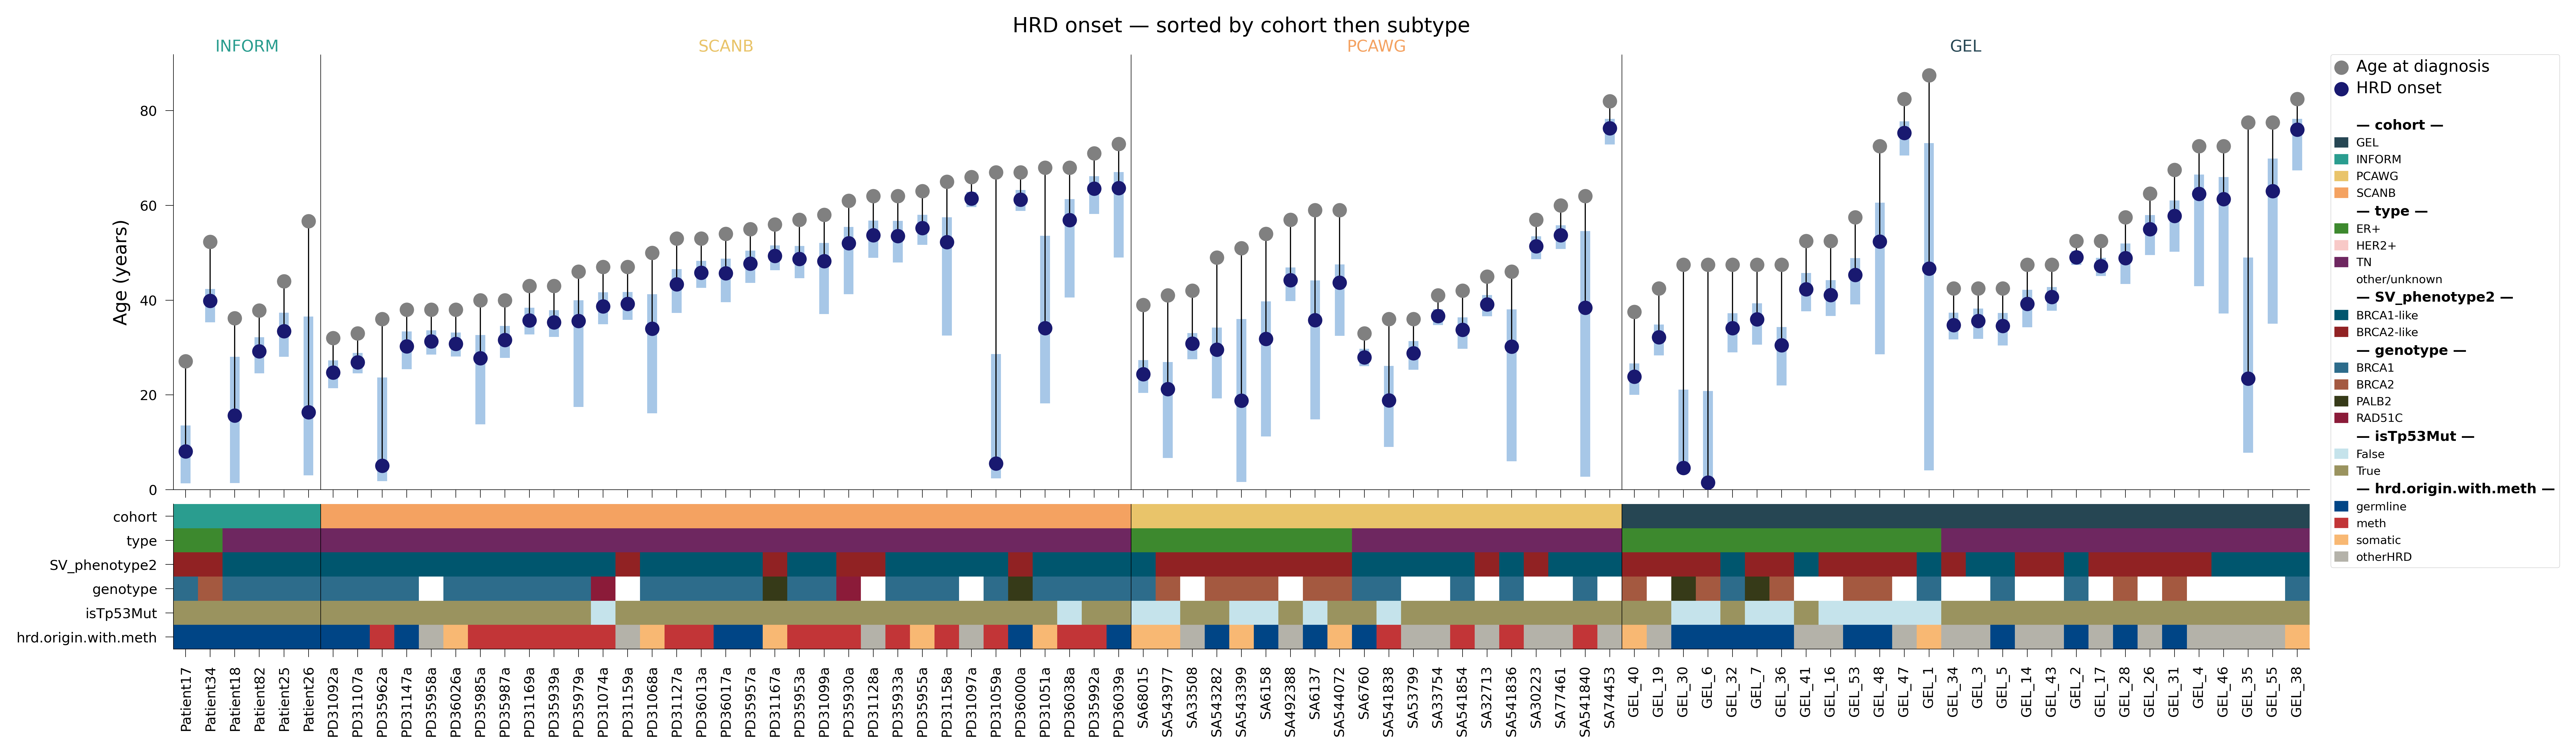

In [4]:
ANNOTATIONS = ["cohort", "type", "SV_phenotype2", "genotype", "isTp53Mut", "hrd.origin.with.meth"]
ROW_COLORS  = {
    "hrd.origin.with.meth": ["#004586", "#C23537", "#F8B873", "#B4B2A9", "#E0E0E0"],
    "type":                 ["#3D892E", "#F8C9C7", "#6E2760"],
    "isTp53Mut":            ["#C5E3EB", "#9A935F", "#692A10"],
    "SV_phenotype2":        ["#00566E", "#912223"],
    "cohort":               ["#264653", "#2A9D8F", "#E9C46A", "#F4A261", "#E76F51"],
    "genotype":             ["#2D6C8B", "#A45940", "#363A18", "#8B1B39", "#D4A017",
                             "#2E8B57", "#8B0000", "#4682B4", "#556B2F", "#888888"],
}

# summary needs the crossing-age columns; drop samples without a gradual estimate
summary = df.dropna(subset=["HRD_crossing_age_median", "age_at_diagnosis"]).copy()
summary_sorted = (
    summary
    .assign(
        _cr=lambda d: d["cohort"].map({c: i for i, c in enumerate(COHORT_ORDER)}).fillna(99),
        _tr=lambda d: d["type"].map({t: i for i, t in enumerate(TYPE_ORDER)}).fillna(99),
    )
    .sort_values(["_cr", "_tr", "age_at_diagnosis"])
    .drop(columns=["_cr", "_tr"])
)
sample_order = summary_sorted["sample"].tolist()
cohort_col   = summary_sorted["cohort"].tolist()

sep_lines = [i - 0.5 for i in range(1, len(cohort_col)) if cohort_col[i] != cohort_col[i - 1]]
cohort_pos = {}
for i, c in enumerate(cohort_col):
    cohort_pos.setdefault(c, []).append(i)
sep_labels = [((p[0] + p[-1]) / 2, c, COHORT_COLORS.get(c, "black")) for c, p in cohort_pos.items()]

meta_df = (
    df[["sample", "type", "hrd.origin.with.meth", "genotype",
        "isTp53Mut", "SV_phenotype2", "cohort"]]
    .drop_duplicates("sample").set_index("sample")
    .assign(
        SV_phenotype2=lambda d: d["SV_phenotype2"].replace(
            {"BRCA1": "BRCA1-like", "BRCA2": "BRCA2-like"}),
        **{"hrd.origin.with.meth": lambda d: d["hrd.origin.with.meth"].fillna("otherHRD")},
    )
)

set_mpl_style()
fig1 = plot_hrd_onset(
    summary_df=summary, sample_order=sample_order, meta_df=meta_df,
    annotations=ANNOTATIONS, annotation_colors=ROW_COLORS,
    sep_lines=sep_lines, sep_labels=sep_labels,
    title="HRD onset — sorted by cohort then subtype",
    dot_size=6, ci_bar_width_scale=4.0,
)
fig1.savefig(f"{OUTPUT_DIR}/fig5a_HRD_onset_lollipop_by_cohort_subtype.pdf", bbox_inches="tight")
plt.show()

## Fig 2 — HRD Duration distributions: Gradual vs Two-Step vs HRDTime

Two-Step Median: BH-adj p = 1.15e-06 (***)
Gradual: BH-adj p = 2.10e-06 (***)
HRDTime: p = 7.50e-02 (ns)


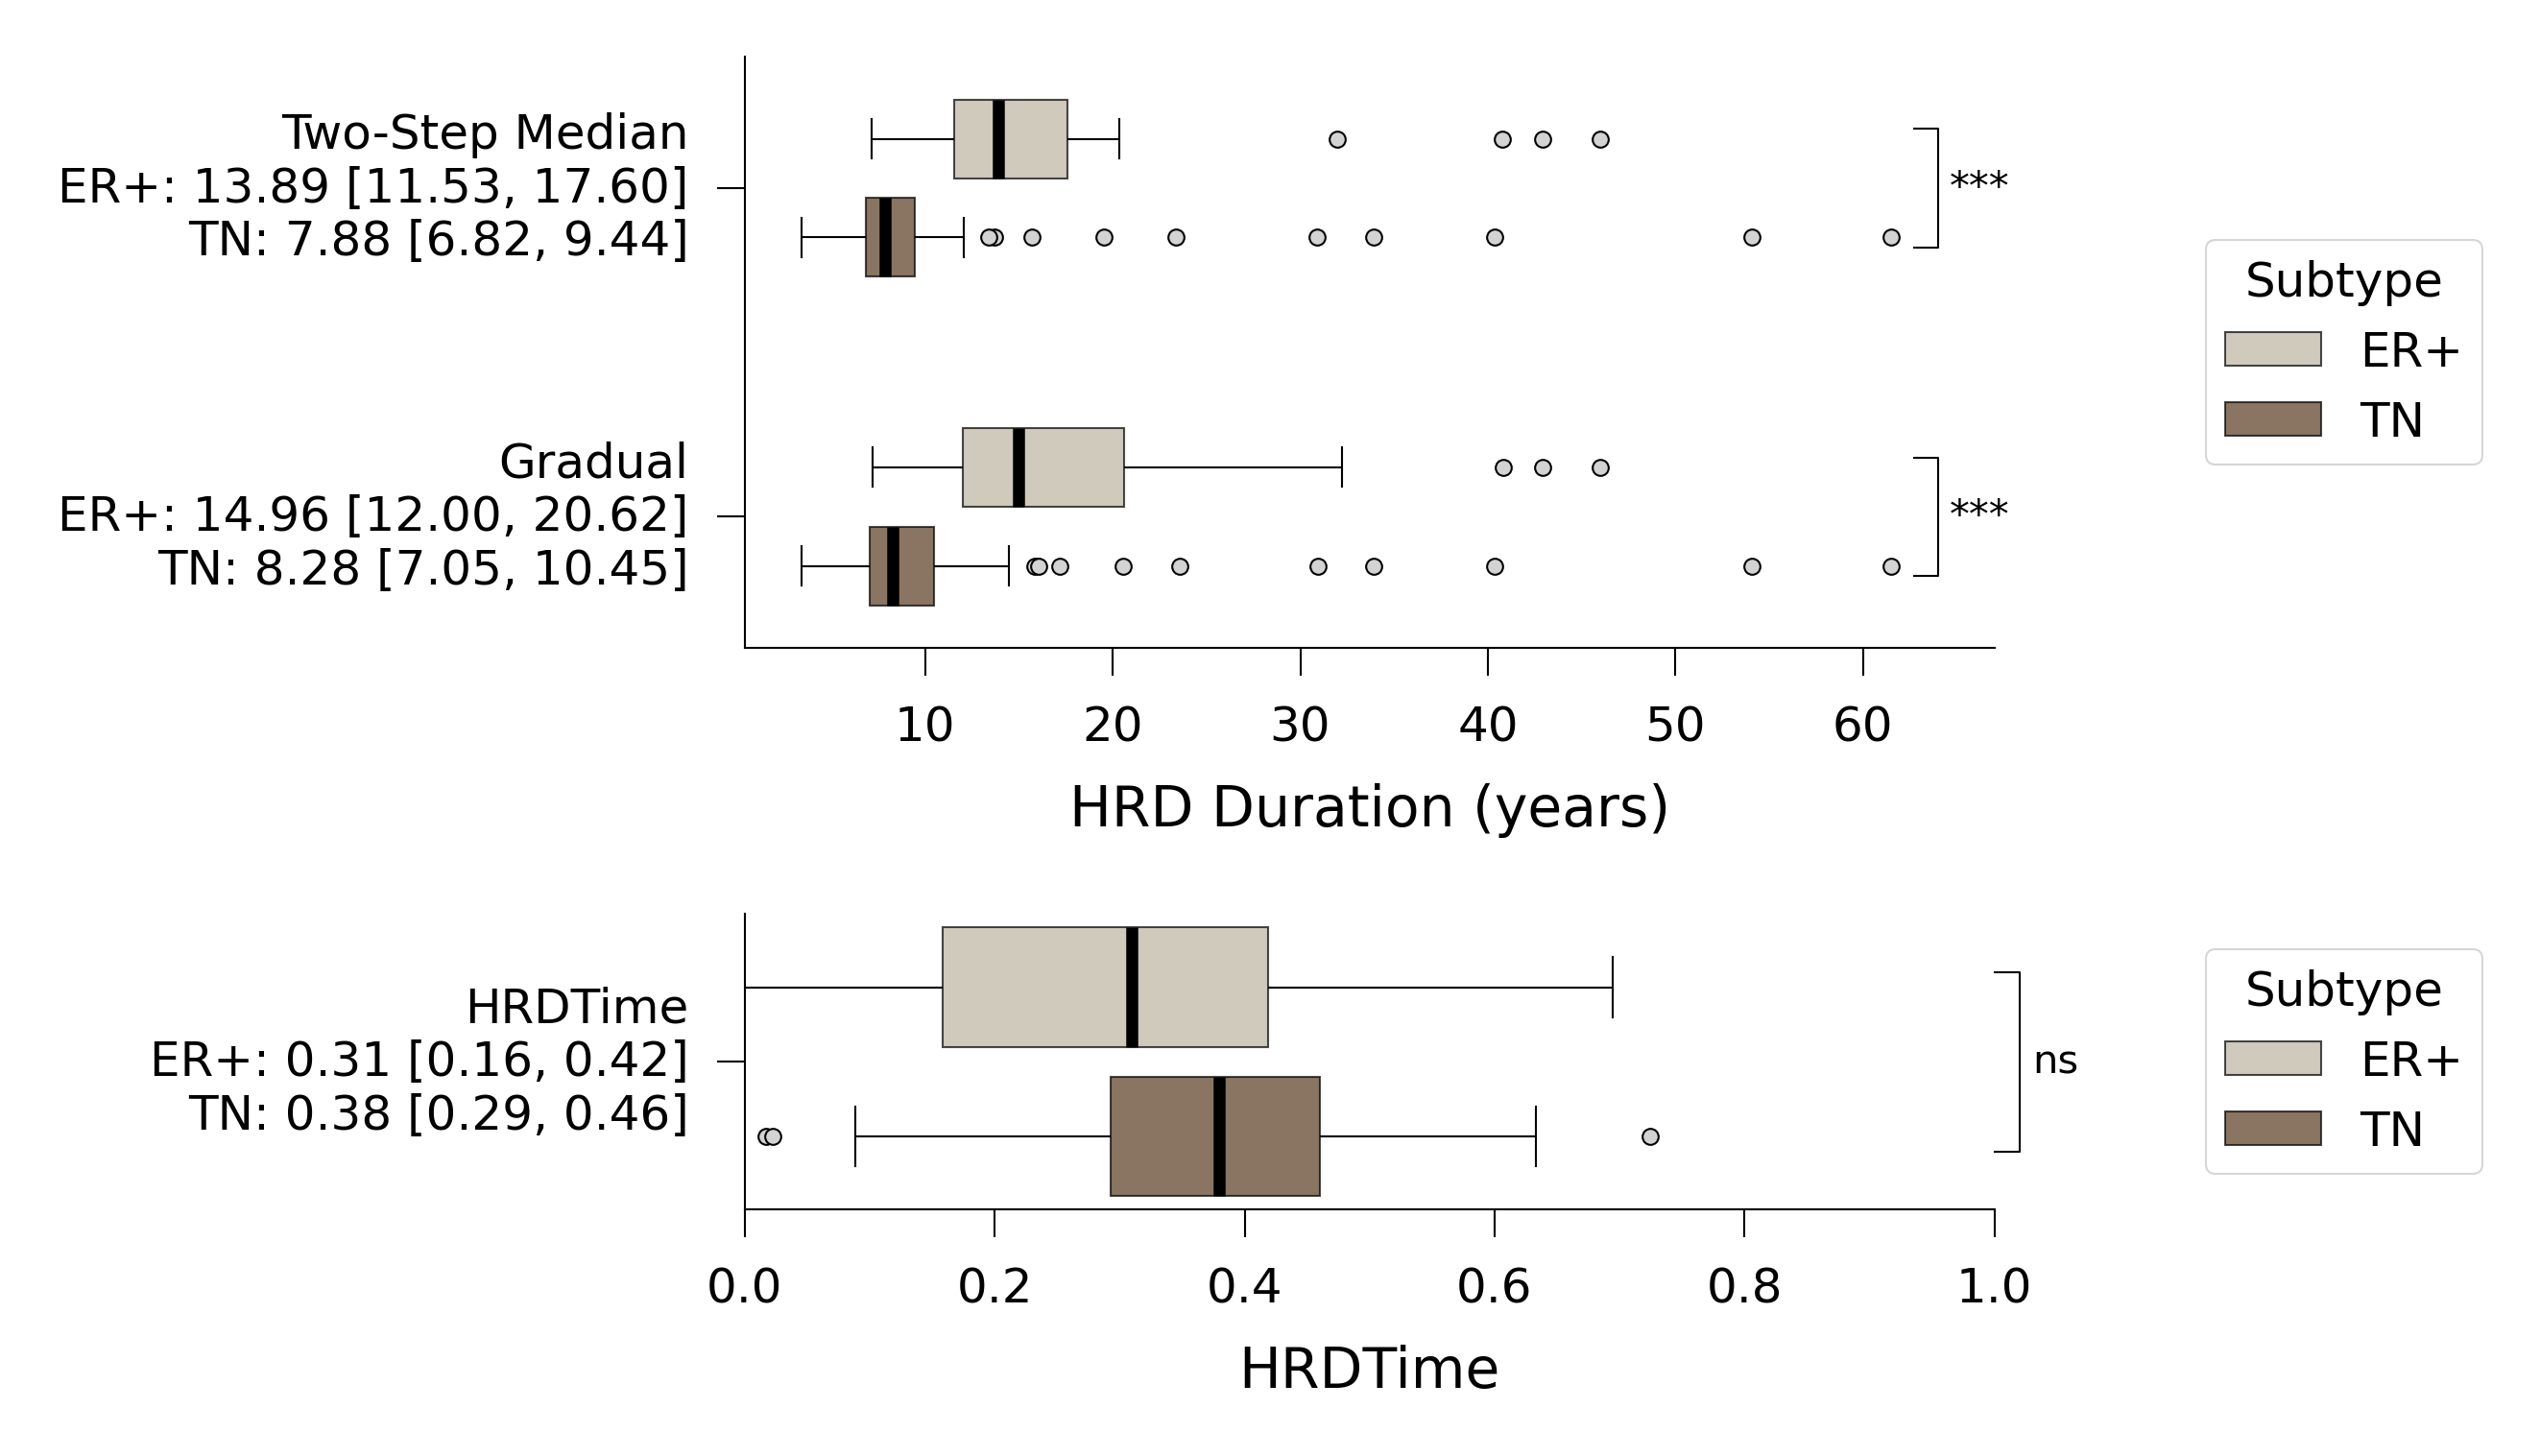

In [5]:
set_mpl_style()

PALETTE_SUBTYPE = {"ER+": "#c2b69d", "TN": "#603a16"}
HUE_ORDER       = ["ER+", "TN"]
MODEL_ORDER     = ["Two-Step Median", "Gradual"]
GAP, W1, W2     = 0.2, 0.6, 0.2

def bracket(ax, x, y0, y1, label):
    t = x * 1.02
    ax.plot([x, t, t, x], [y0, y0, y1, y1], lw=0.25, color="black", clip_on=False)
    ax.text(t * 1.01, (y0 + y1) / 2, label, ha="left", va="center", fontsize=5)

def hue_off(w): return (w / 2) * (1 + GAP) / 2

def mwu_p(d, col, model_name=None):
    sub = d[d["model"] == model_name] if model_name else d
    a = sub[sub["type"] == "ER+"][col]; b = sub[sub["type"] == "TN"][col]
    return mannwhitneyu(a, b, alternative="two-sided").pvalue if len(a) and len(b) else np.nan

def row_label(d, col, name):
    parts = [name]
    for t in HUE_ORDER:
        s = d[d["type"] == t][col]
        if len(s):
            parts.append(f"{t}: {s.median():.2f} [{s.quantile(.25):.2f}, {s.quantile(.75):.2f}]")
    return "\n".join(parts)

def style_ax(ax, ytick_labels, xlabel, xlim=None):
    ax.set(ylabel="", xlabel=xlabel)
    if xlim: ax.set_xlim(xlim)
    ax.xaxis.label.set_fontsize(7)
    ax.set_yticklabels(ytick_labels, fontsize=6, va="center")
    leg = ax.legend(title="Subtype", fontsize=6, title_fontsize=6,
                    loc="center left", bbox_to_anchor=(1.15, 0.5), frameon=True)
    leg.get_frame().set_linewidth(SPINE_LW)
    for sp in ax.spines.values(): sp.set_linewidth(SPINE_LW)
    ax.tick_params(width=SPINE_LW, labelsize=6)

# per-sample duration medians straight from the table
sub = df[df["type"].isin(HUE_ORDER)]
duration_df = pd.concat([
    sub[["sample", "type", "HRD_Duration_median"]].dropna()
        .rename(columns={"HRD_Duration_median": "HRD_Duration"}).assign(model="Gradual"),
    sub[["sample", "type", "TS_Duration_median"]].dropna()
        .rename(columns={"TS_Duration_median": "HRD_Duration"}).assign(model="Two-Step Median"),
], ignore_index=True)

hrdtime_df = (
    df[["sample", "type", "HRDTime"]].dropna(subset=["HRDTime"])
    .pipe(lambda d: d[d["type"].isin(HUE_ORDER)]).assign(model="HRDTime")
)

p_raw   = [mwu_p(duration_df, "HRD_Duration", m) for m in MODEL_ORDER]
p_adj   = multipletests([p for p in p_raw if not np.isnan(p)], method="fdr_bh")[1]
p_hrdtime = mwu_p(hrdtime_df, "HRDTime")
for m, pa in zip(MODEL_ORDER, p_adj):
    print(f"{m}: BH-adj p = {pa:.2e} ({stars(pa)})")
print(f"HRDTime: p = {p_hrdtime:.2e} ({stars(p_hrdtime)})")

fig2, (ax1, ax2) = plt.subplots(2, 1, figsize=(2.8, 2.6),
                                gridspec_kw=dict(height_ratios=[2, 1], hspace=0.6))
sns.boxplot(data=duration_df, y="model", x="HRD_Duration", hue="type",
            order=MODEL_ORDER, hue_order=HUE_ORDER, palette=PALETTE_SUBTYPE,
            width=W1, gap=GAP, orient="h", ax=ax1, **BOX_PROPS)
for p in ax1.patches: p.set_alpha(0.7)
style_ax(ax1, [row_label(duration_df[duration_df["model"] == m], "HRD_Duration", m) for m in MODEL_ORDER],
         "HRD Duration (years)")
ax1.set_ylim(1.4, -0.4)
x_br = duration_df["HRD_Duration"].max() * 1.02
for i, pa in enumerate(p_adj):
    bracket(ax1, x_br, i - hue_off(W1), i + hue_off(W1), stars(pa))

sns.boxplot(data=hrdtime_df, y="model", x="HRDTime", hue="type",
            order=["HRDTime"], hue_order=HUE_ORDER, palette=PALETTE_SUBTYPE,
            width=W2, gap=GAP, orient="h", ax=ax2, **BOX_PROPS)
for p in ax2.patches: p.set_alpha(0.7)
style_ax(ax2, [row_label(hrdtime_df, "HRDTime", "HRDTime")], "HRDTime", xlim=(0, 1))
bracket(ax2, 1.0, -hue_off(W2), hue_off(W2), stars(p_hrdtime))

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig5b_HRD_duration_gradual_vs_twostep_vs_HRDTime_by_subtype.pdf", bbox_inches="tight")
plt.show()

## Fig 3 — TP53 mutation status vs HRD Duration

TP53 mut vs HRD Duration: BH-adj p = 1.09e-04 (***)


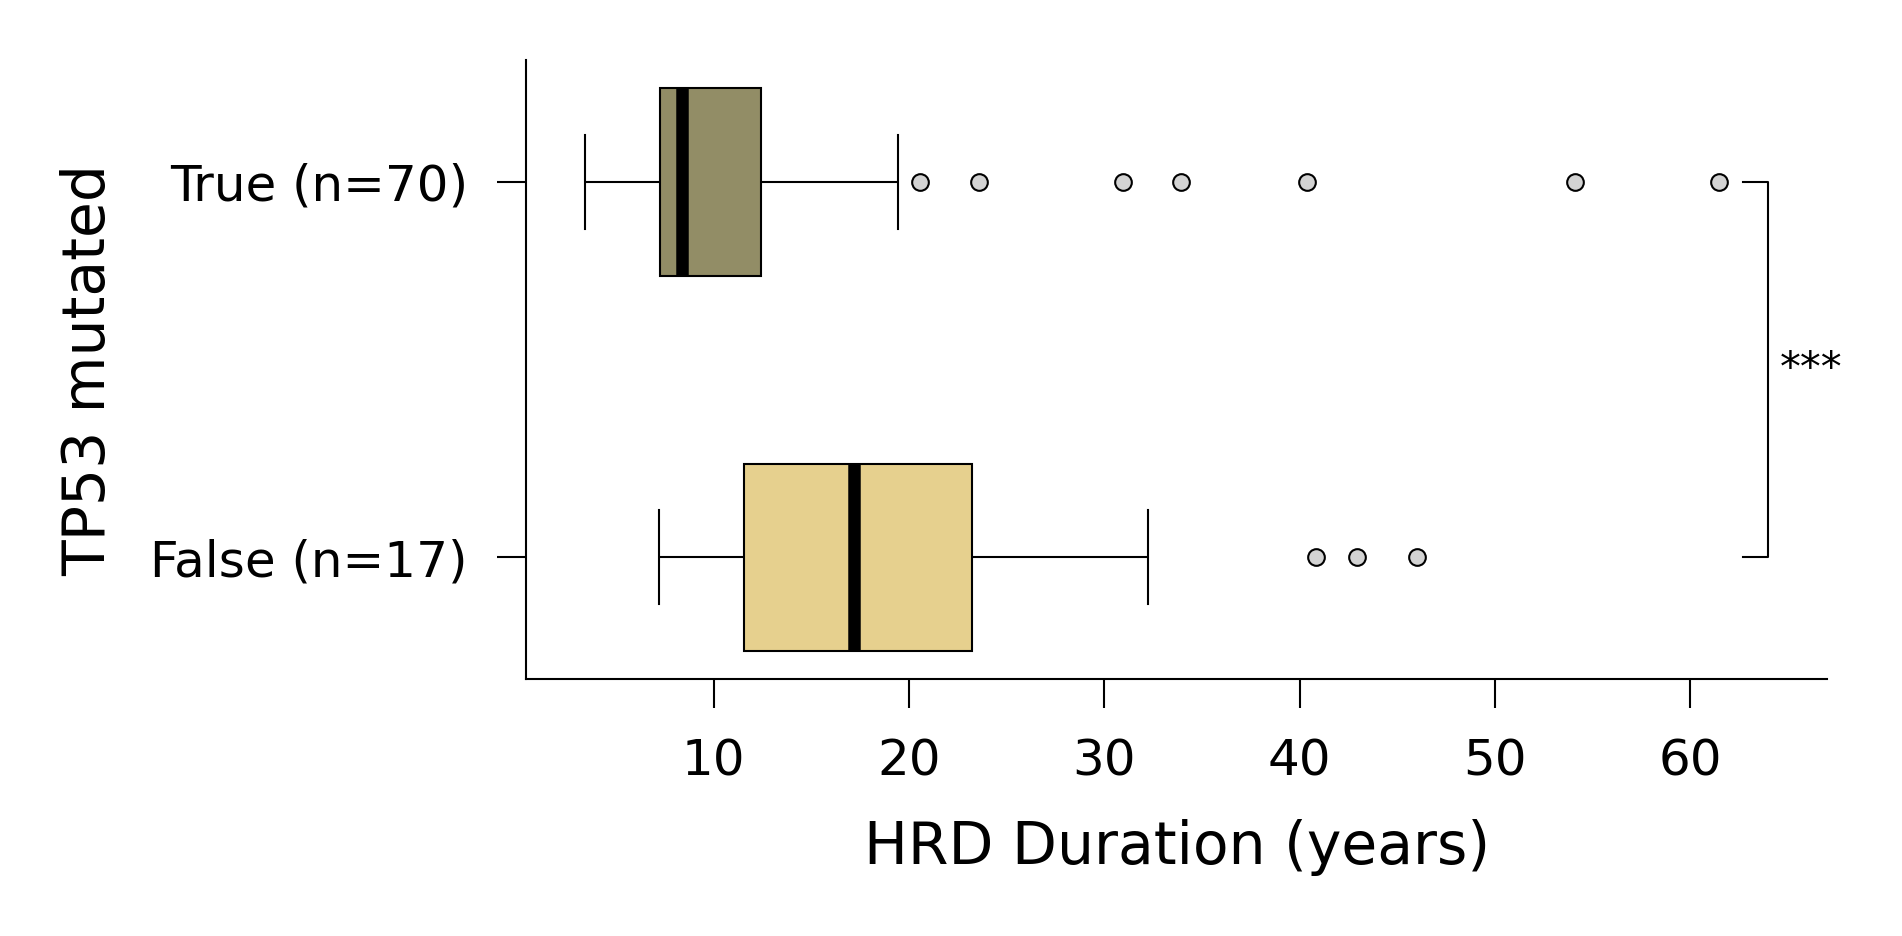

In [6]:
set_mpl_style()
PALETTE_TP53 = {"True": "#99935f", "False": "#f5d77f"}

tp53_df = (
    df[["sample", "HRD_Duration_median", "isTp53Mut"]]
    .rename(columns={"HRD_Duration_median": "HRD_Duration"})
    .dropna(subset=["isTp53Mut", "HRD_Duration"])
    .assign(isTp53Mut=lambda d: d["isTp53Mut"].astype(bool))
)
n_t = tp53_df["isTp53Mut"].sum(); n_f = (~tp53_df["isTp53Mut"]).sum()
p_raw = mannwhitneyu(tp53_df.loc[tp53_df["isTp53Mut"], "HRD_Duration"],
                     tp53_df.loc[~tp53_df["isTp53Mut"], "HRD_Duration"],
                     alternative="two-sided").pvalue
p_adj = multipletests([p_raw], method="fdr_bh")[1][0]
print(f"TP53 mut vs HRD Duration: BH-adj p = {p_adj:.2e} ({stars(p_adj)})")

fig3, ax = plt.subplots(figsize=(3.2, 1.6))
sns.boxplot(data=tp53_df, y="isTp53Mut", x="HRD_Duration", order=[True, False],
            palette=PALETTE_TP53, width=0.5, orient="h", ax=ax, **BOX_PROPS)
for p in ax.patches:
    if p.get_facecolor()[:3] == mcolors.to_rgb(PALETTE_TP53["False"]): p.set_alpha(0.9)
ax.set(xlabel="HRD Duration (years)", ylabel="TP53 mutated")
ax.xaxis.label.set_fontsize(7); ax.yaxis.label.set_fontsize(7)
ax.set_yticklabels([f"True (n={n_t})", f"False (n={n_f})"], fontsize=6)
for sp in ax.spines.values(): sp.set_linewidth(SPINE_LW)
ax.tick_params(width=SPINE_LW, labelsize=6)
x_br = tp53_df["HRD_Duration"].max() * 1.02
ax.plot([x_br, x_br*1.02, x_br*1.02, x_br], [0, 0, 1, 1], lw=0.25, color="black", clip_on=False)
ax.text(x_br*1.03, 0.5, stars(p_adj), ha="left", va="center", fontsize=5)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig5c_HRD_duration_by_TP53_status.pdf", bbox_inches="tight")
plt.show()

## Fig 4 — HRD metrics by HRD origin (3-panel: Duration, HRDTime, Age)


HRD Duration  —  Mann-Whitney U (BH-corrected)
  germline vs somatic: n=28/12  p_raw=5.649e-01  p_BH=6.779e-01  ns
  germline vs meth: n=28/21  p_raw=7.086e-01  p_BH=7.086e-01  ns
  germline vs otherHRD: n=28/12  p_raw=3.015e-03  p_BH=6.031e-03  **
  somatic vs meth: n=12/21  p_raw=4.210e-01  p_BH=6.316e-01  ns
  somatic vs otherHRD: n=12/12  p_raw=2.437e-03  p_BH=6.031e-03  **
  meth vs otherHRD: n=21/12  p_raw=1.207e-03  p_BH=6.031e-03  **

HRDTime  —  Mann-Whitney U (BH-corrected)
  germline vs somatic: n=32/15  p_raw=8.284e-01  p_BH=9.637e-01  ns
  germline vs meth: n=32/21  p_raw=9.637e-01  p_BH=9.637e-01  ns
  germline vs otherHRD: n=32/12  p_raw=5.839e-04  p_BH=1.752e-03  **
  somatic vs meth: n=15/21  p_raw=8.725e-01  p_BH=9.637e-01  ns
  somatic vs otherHRD: n=15/12  p_raw=3.692e-03  p_BH=7.385e-03  **
  meth vs otherHRD: n=21/12  p_raw=1.963e-04  p_BH=1.178e-03  **


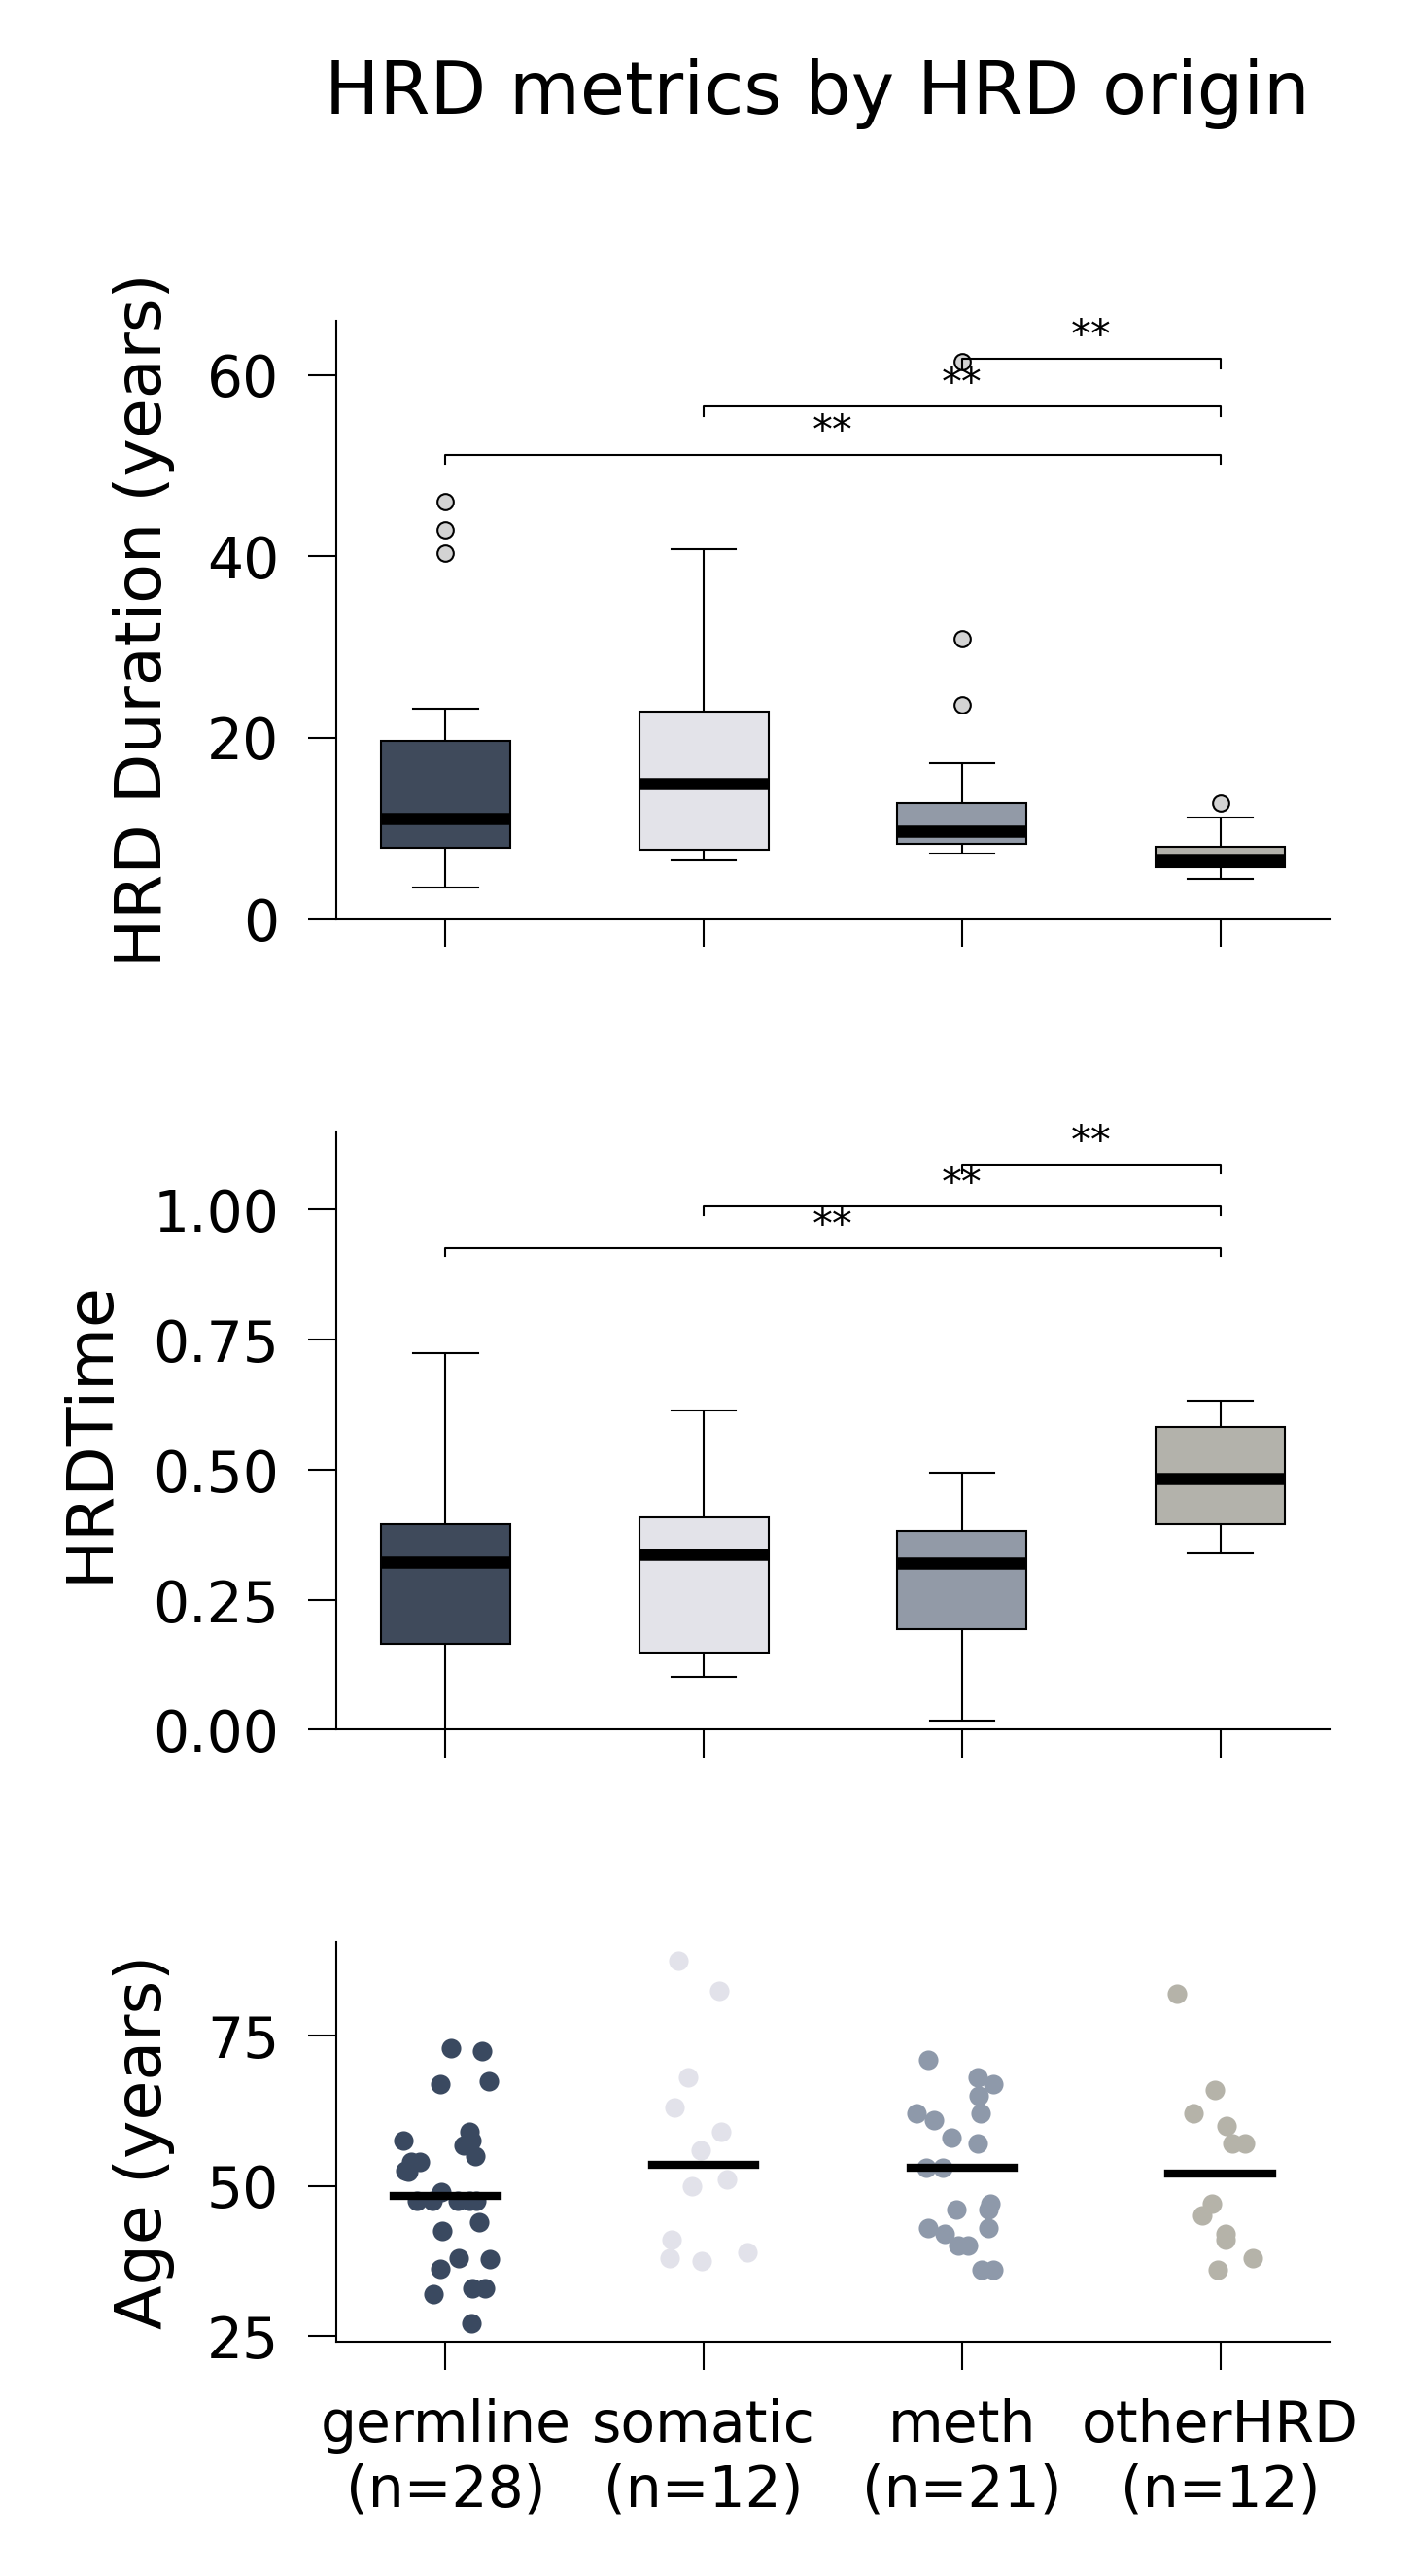

In [7]:
set_mpl_style()
PALETTE_ORIGIN = {"somatic": "#e2e2ea", "meth": "#8e99aa",
                  "germline": "#3a4960", "otherHRD": "#b5b3a9"}
ORIGIN_ORDER = ["germline", "somatic", "meth", "otherHRD"]

def bh_test(d, grp, val, order):
    pairs = list(combinations(order, 2))
    raw = [mannwhitneyu(d[d[grp]==g1][val], d[d[grp]==g2][val], alternative="two-sided")[1]
           if (d[grp]==g1).sum()>1 and (d[grp]==g2).sum()>1 else np.nan for g1, g2 in pairs]
    corr = {i: np.nan for i in range(len(pairs))}
    valid = [(i, p) for i, p in enumerate(raw) if not np.isnan(p)]
    if valid:
        idxs, pv = zip(*valid); _, c, _, _ = multipletests(pv, method="fdr_bh"); corr.update(zip(idxs, c))
    return pairs, raw, corr

def print_stats(label, d, grp, val, order):
    pairs, raw, corr = bh_test(d, grp, val, order)
    print(f"\n{'='*70}\n{label}  —  Mann-Whitney U (BH-corrected)\n{'='*70}")
    for i, (g1, g2) in enumerate(pairs):
        n1=(d[grp]==g1).sum(); n2=(d[grp]==g2).sum()
        pr=f"{raw[i]:.3e}" if not np.isnan(raw[i]) else "NaN"
        pb=f"{corr[i]:.3e}" if not np.isnan(corr[i]) else "NaN"
        print(f"  {g1} vs {g2}: n={n1}/{n2}  p_raw={pr}  p_BH={pb}  {stars(corr[i])}")
    return pairs, corr

def sig_brackets(ax, pairs, corr, order, y_lim, y_step):
    sig = [(pairs[i], stars(corr[i])) for i in range(len(pairs)) if stars(corr[i]) not in ("", "ns")]
    for lvl, (pair, star) in enumerate(sig):
        if pair[0] not in order or pair[1] not in order: continue
        x1, x2 = order.index(pair[0]), order.index(pair[1])
        y = y_lim - y_step * (len(sig) - lvl)
        ax.plot([x1, x1, x2, x2], [y, y+y_step*0.2, y+y_step*0.2, y], lw=0.25, color="black", clip_on=False)
        ax.text((x1+x2)/2, y+y_step*0.25, star, ha="center", va="bottom", fontsize=5, clip_on=False)

# Duration & age panels: age-translation-timed samples (those with a duration).
# HRDTime panel: every sample with a molecular HRDTime estimate.
# Samples without an annotated origin are excluded (not folded into otherHRD).
timed = df[df["HRD_Duration_median"].notna()]
dur_or = (timed[["sample", "hrd.origin.with.meth", "HRD_Duration_median"]]
          .rename(columns={"HRD_Duration_median": "HRD_Duration"})
          .dropna(subset=["hrd.origin.with.meth", "HRD_Duration"])
          .pipe(lambda d: d[d["hrd.origin.with.meth"].isin(ORIGIN_ORDER)]))
hrdtime_or = (df[["sample", "hrd.origin.with.meth", "HRDTime"]].dropna(subset=["HRDTime"])
              .pipe(lambda d: d[d["hrd.origin.with.meth"].isin(ORIGIN_ORDER)]))
# age_plot = age_at_diagnosis (age-band midpoint for the GEL cohort)
age_or = (timed[["sample", "hrd.origin.with.meth", "age_at_diagnosis"]]
          .rename(columns={"age_at_diagnosis": "age_plot"})
          .pipe(lambda d: d[d["hrd.origin.with.meth"].isin(ORIGIN_ORDER)])
          .dropna(subset=["hrd.origin.with.meth", "age_plot"]))

origin_present = [o for o in ORIGIN_ORDER if o in dur_or["hrd.origin.with.meth"].unique()]
dur_pairs, dur_corr = print_stats("HRD Duration", dur_or, "hrd.origin.with.meth", "HRD_Duration", origin_present)
hrd_pairs, hrd_corr = print_stats("HRDTime", hrdtime_or, "hrd.origin.with.meth", "HRDTime", origin_present)
# NOTE: age is shown as a dot plot only (visualization); no p-values are computed for age
# — statistics are reported for HRD duration and HRDTime. For GEL, 'age_plot' is the
# 5-year age-band midpoint (reconstructed at load; exact GEL age is not disclosed).

fig4 = plt.figure(figsize=(2.2, 4.5))
gs = gridspec.GridSpec(3, 1, height_ratios=[3, 3, 2], hspace=0.4)
ax1 = fig4.add_subplot(gs[0]); ax2 = fig4.add_subplot(gs[1], sharex=ax1); ax3 = fig4.add_subplot(gs[2], sharex=ax1)

sns.boxplot(data=dur_or, x="hrd.origin.with.meth", y="HRD_Duration", order=origin_present,
            palette=PALETTE_ORIGIN, width=0.5, ax=ax1, **BOX_PROPS)
sig_brackets(ax1, dur_pairs, dur_corr, origin_present, y_lim=66, y_step=66*0.08)
ax1.set_ylim(0, 66); ax1.set(xlabel="", ylabel="HRD Duration (years)"); ax1.yaxis.label.set_fontsize(8)
ax1.tick_params(labelbottom=False, width=SPINE_LW, labelsize=7)
for k, sp in ax1.spines.items(): sp.set_visible(k in ("left", "bottom")); sp.set_linewidth(SPINE_LW)

sns.boxplot(data=hrdtime_or, x="hrd.origin.with.meth", y="HRDTime", order=origin_present,
            palette=PALETTE_ORIGIN, width=0.5, ax=ax2, **BOX_PROPS)
sig_brackets(ax2, hrd_pairs, hrd_corr, origin_present, y_lim=1.15, y_step=0.08)
ax2.set_ylim(0, 1.15); ax2.set(xlabel="", ylabel="HRDTime"); ax2.yaxis.label.set_fontsize(8)
ax2.tick_params(labelbottom=False, width=SPINE_LW, labelsize=7)
for k, sp in ax2.spines.items(): sp.set_visible(k in ("left", "bottom")); sp.set_linewidth(SPINE_LW)

rng = np.random.default_rng(42)
for xi, origin in enumerate(origin_present):
    s = age_or[age_or["hrd.origin.with.meth"] == origin]
    if len(s) == 0: continue
    jit = rng.uniform(-0.18, 0.18, len(s))
    ax3.scatter(xi + jit, s["age_plot"].values, color=PALETTE_ORIGIN.get(origin, "#888888"), s=2, zorder=3)
    ax3.plot([xi-0.2, xi+0.2], [s["age_plot"].median()]*2, color="black", lw=1, zorder=4)
ax3.set(xlabel="", ylabel="Age (years)"); ax3.yaxis.label.set_fontsize(8)
ax3.set_xticks(range(len(origin_present)))
ax3.set_xticklabels([f"{o}\n(n={len(age_or[age_or['hrd.origin.with.meth']==o])})" for o in origin_present], fontsize=5)
for k, sp in ax3.spines.items(): sp.set_visible(k in ("left", "bottom")); sp.set_linewidth(SPINE_LW)
ax3.tick_params(width=SPINE_LW, labelsize=7)

plt.suptitle("HRD metrics by HRD origin", fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig5d_HRD_metrics_by_HRD_origin.pdf", bbox_inches="tight")
plt.show()

## Fig 5 — Ridge regression: predictors of HRD timing

1 − HRDTime:


  alpha=8.2864  R²=0.234  n=115
HRD Duration:


  alpha=33.9322  R²=0.169  n=87


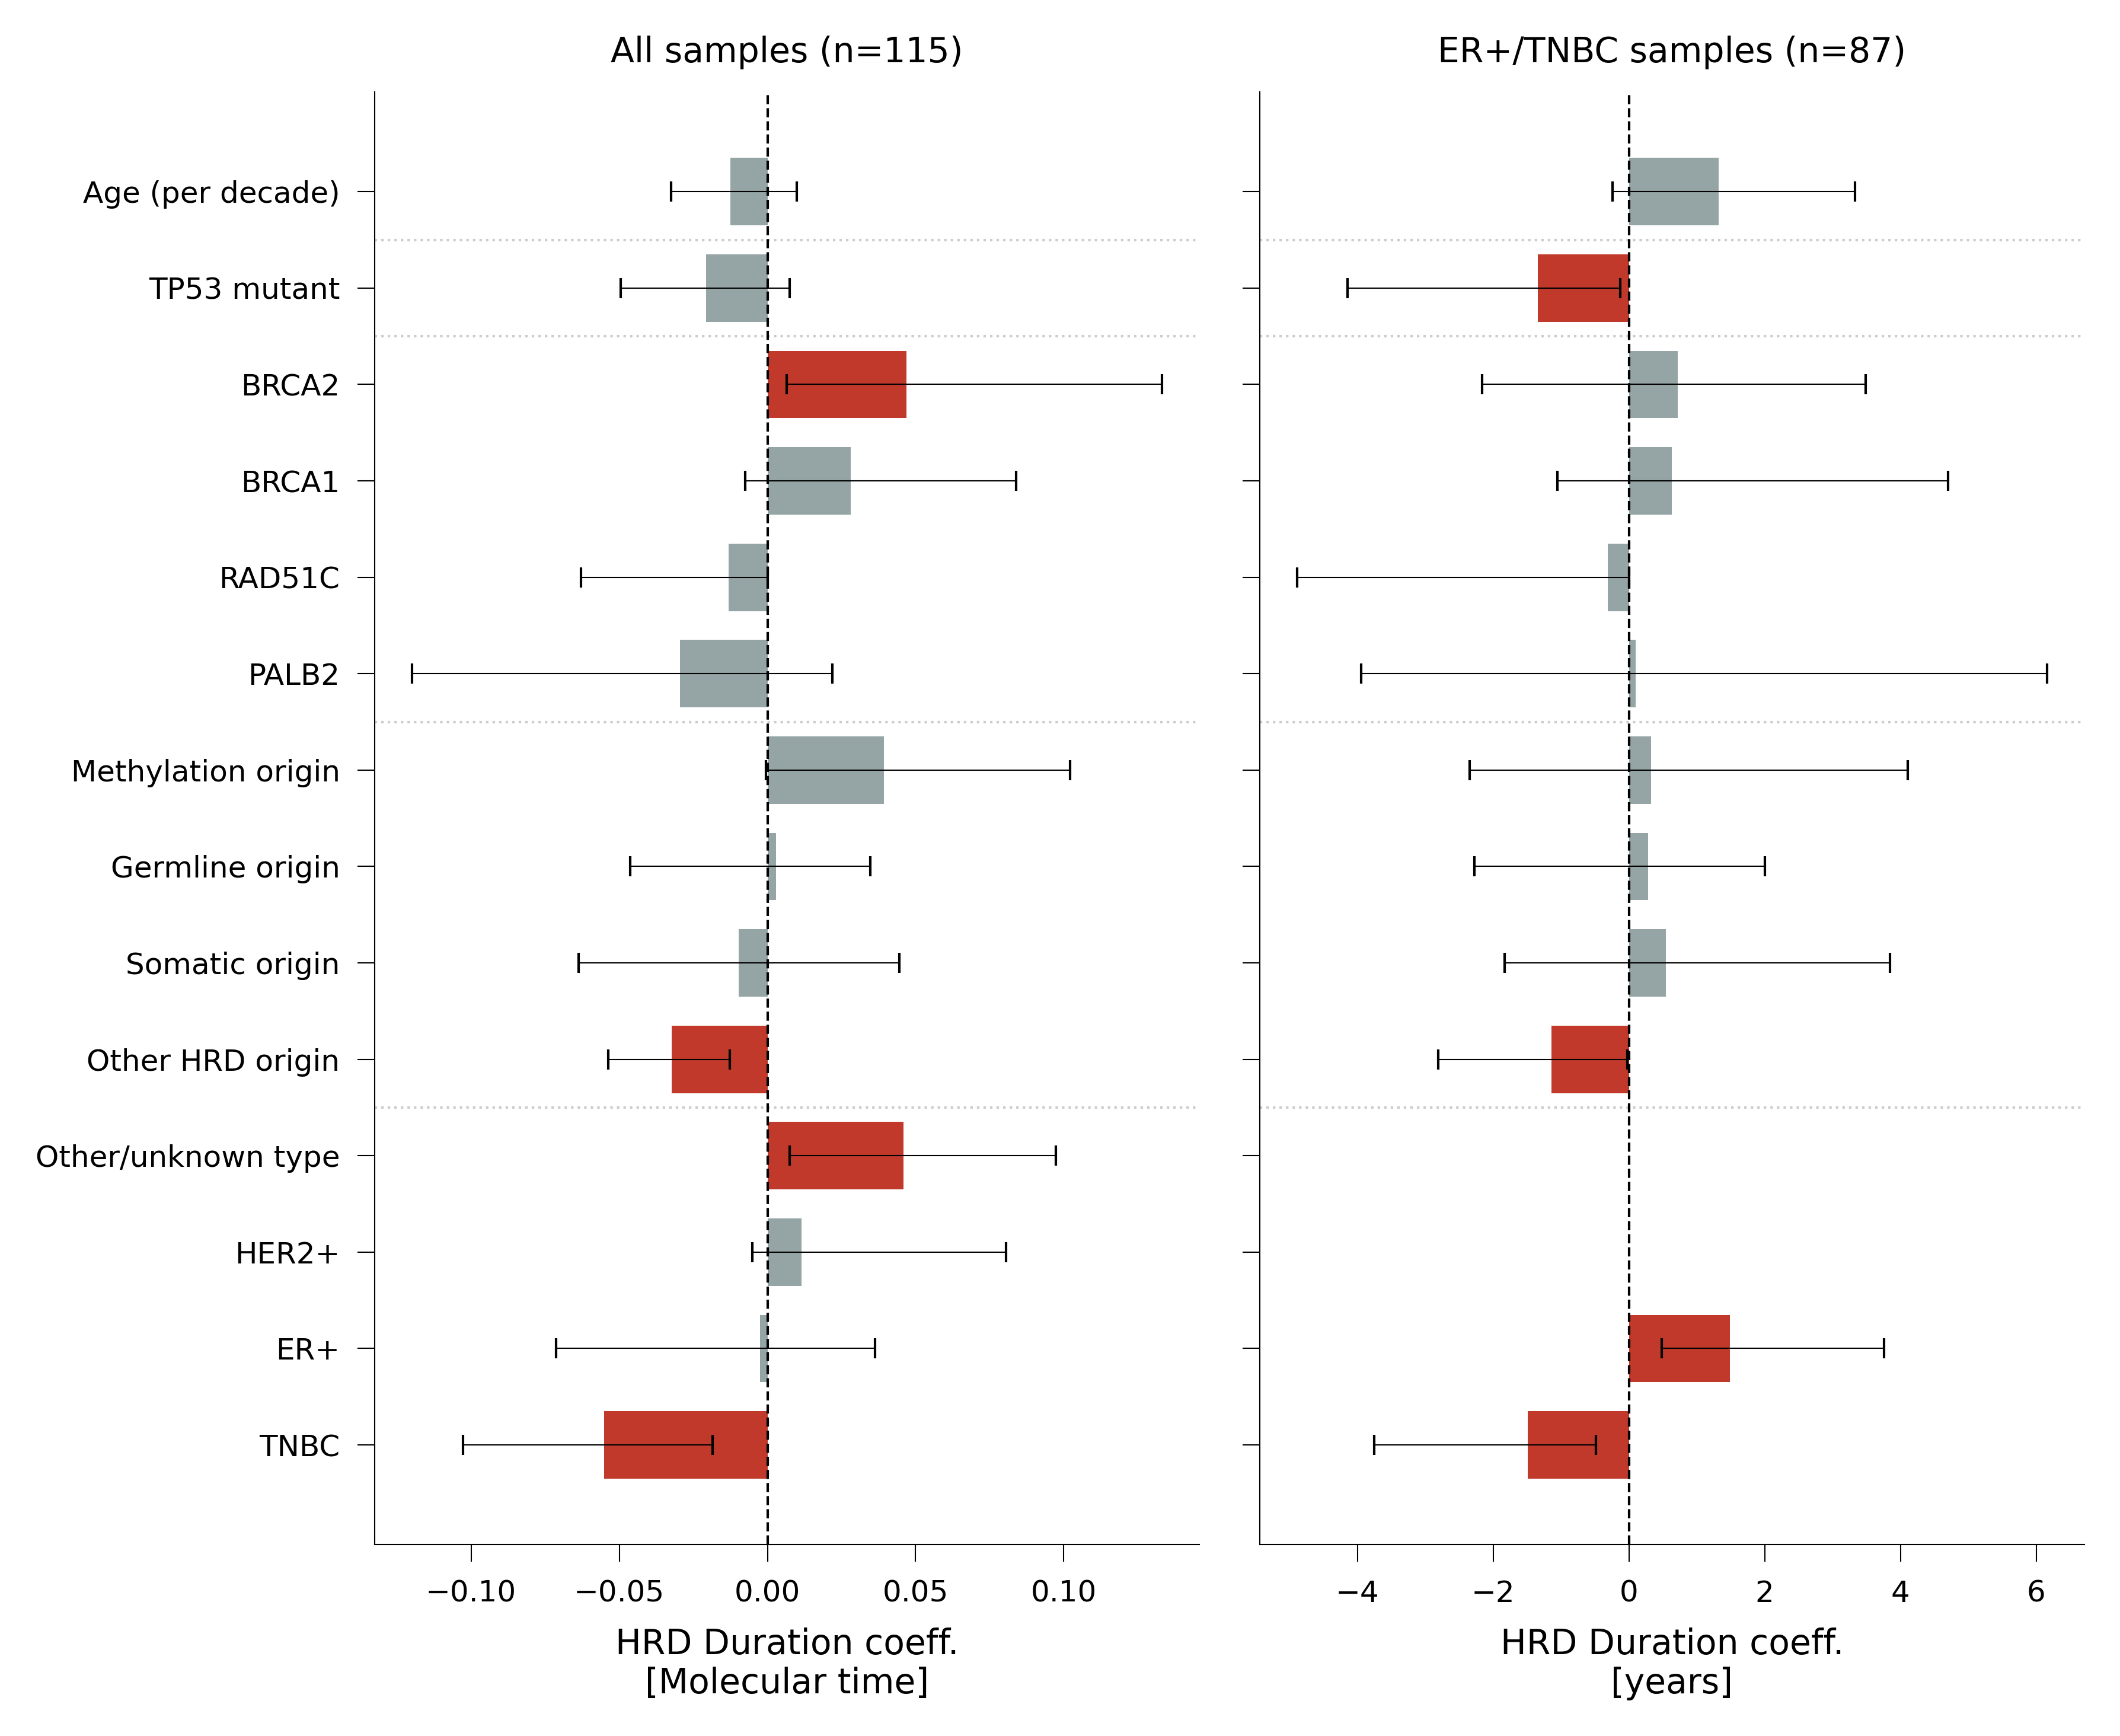

In [8]:
set_mpl_style()

CAT_COLS = ["type", "origin", "genotype_grp", "isTp53Mut"]
NUM_COLS = ["age_per_decade"]
LABEL_MAP = {
    "type_TN": "TNBC", "type_ER+": "ER+", "type_HER2+": "HER2+", "type_other/unknown": "Other/unknown type",
    "origin_otherHRD": "Other HRD origin", "origin_germline": "Germline origin",
    "origin_somatic": "Somatic origin", "origin_meth": "Methylation origin",
    "genotype_grp_BRCA1": "BRCA1", "genotype_grp_BRCA2": "BRCA2", "genotype_grp_PALB2": "PALB2",
    "genotype_grp_RAD51C": "RAD51C", "genotype_grp_no_known_mutation": "No known mutation",
    "isTp53Mut_0": "TP53 wildtype", "isTp53Mut_1": "TP53 mutant", "age_per_decade": "Age (per decade)",
}
DROP_LABELS = {"TP53 wildtype", "No known mutation"}
GROUPS = {
    "Tumour type": lambda f: f.startswith("type_"),
    "HRD origin":  lambda f: f.startswith("origin_"),
    "Genotype":    lambda f: f.startswith("genotype_grp_"),
    "TP53":        lambda f: f in ("isTp53Mut_0", "isTp53Mut_1"),
    "Age":         lambda f: f == "age_per_decade",
}

def prep_ridge(d, target_col):
    d = d.copy()
    d["hrd.origin.with.meth"] = (d["hrd.origin.with.meth"]
        .replace({"other/unknown": "otherHRD", "unknown": "otherHRD", "other": "otherHRD"}).fillna("otherHRD"))
    d["origin"] = d["hrd.origin.with.meth"]
    d["genotype_grp"] = d["genotype"].apply(
        lambda g: g if pd.notna(g) and g in ["BRCA1", "BRCA2", "PALB2", "RAD51C"] else "no_known_mutation")
    d["isTp53Mut"] = d["isTp53Mut"].map({True: 1, False: 0}).fillna(0).astype(str)
    d["age_per_decade"] = d["age_at_diagnosis"] / 10   # real age (non-GEL) / band midpoint (GEL)
    return d.dropna(subset=[target_col] + [c for c in CAT_COLS + NUM_COLS if c in d.columns])

def run_ridge(d, target_col, cat_cols=CAT_COLS, num_cols=NUM_COLS, seed=43):
    pre = ColumnTransformer([("cat", OneHotEncoder(drop=None, sparse_output=False), cat_cols),
                             ("num", "passthrough", num_cols)])
    X = pre.fit_transform(d); y = d[target_col].values
    fn = pre.named_transformers_["cat"].get_feature_names_out(cat_cols).tolist() + num_cols
    fdf = pd.DataFrame(X, columns=fn)
    ridge = RidgeCV(alphas=np.logspace(-3, 3, 50)).fit(fdf, y)
    rng = np.random.default_rng(seed)
    boots = np.array([RidgeCV(alphas=np.logspace(-3, 3, 20))
                      .fit(*resample(fdf.values, y, random_state=int(rng.integers(1_000_000_000)))).coef_
                      for _ in range(500)])
    coef = pd.DataFrame({"feature": fn, "coef": ridge.coef_,
                         "lo": np.percentile(boots, 2.5, axis=0), "hi": np.percentile(boots, 97.5, axis=0)})
    coef["sig"] = (coef["lo"] > 0) | (coef["hi"] < 0)
    print(f"  alpha={ridge.alpha_:.4f}  R\u00b2={ridge.score(fdf, y):.3f}  n={len(y)}")
    return coef, ridge.score(fdf, y), len(y)

def order_and_label(coef, ref=None, groups=GROUPS, label_map=LABEL_MAP, drop=DROP_LABELS):
    src = ref if ref is not None else coef
    ordered = []
    for _, belongs in groups.items():
        ordered.extend(src[src["feature"].apply(belongs)].sort_values("coef")["feature"].tolist())
    ordered += [f for f in coef["feature"] if f not in ordered]
    coef = (coef.set_index("feature").reindex(ordered).reset_index()
            .assign(label=lambda d: d["feature"].map(label_map).fillna(d["feature"])))
    coef = coef[~coef["label"].isin(drop)].reset_index(drop=True)
    labels, dividers = coef["label"].tolist(), []
    for _, belongs in groups.items():
        gl = [label_map.get(f, f) for f in ordered if belongs(f) and label_map.get(f, f) not in drop]
        if gl and gl[-1] in labels and labels.index(gl[-1]) < len(labels) - 1:
            dividers.append(labels.index(gl[-1]) + 0.5)
    return coef, dividers

META = ["sample", "hrd.origin.with.meth", "genotype", "type", "scaled_SBS1",
        "isTp53Mut", "age_at_diagnosis"]

hrdtime_ridge = prep_ridge(df[META + ["HRDTime"]].dropna(subset=["HRDTime"]), "HRDTime")
hrdtime_ridge["oneMinusHRDTime"] = 1 - hrdtime_ridge["HRDTime"]

dur_ridge = prep_ridge(
    df[df["type"].isin(["ER+", "TN"])][META + ["HRD_Duration_median"]]
    .rename(columns={"HRD_Duration_median": "HRD_Duration"}), "HRD_Duration")

print("1 − HRDTime:"); coef_t, r2_t, n_t = run_ridge(hrdtime_ridge, "oneMinusHRDTime")
print("HRD Duration:");   coef_d, r2_d, n_d = run_ridge(dur_ridge, "HRD_Duration")

coef_t, dividers = order_and_label(coef_t)
coef_d, _        = order_and_label(coef_d, ref=coef_t)

fig5, axes = plt.subplots(1, 2, figsize=(6, len(coef_t) * 0.28 + 1), sharey=True)
for ax, cdf, n, xlabel in zip(axes, [coef_t, coef_d], [n_t, n_d],
        ["HRD Duration coeff.\n[Molecular time]", "HRD Duration coeff.\n[years]"]):
    ax.barh(cdf["label"], cdf["coef"], xerr=[cdf["coef"] - cdf["lo"], cdf["hi"] - cdf["coef"]],
            color=["#c0392b" if s else "#95a5a6" for s in cdf["sig"]], height=0.7,
            error_kw=dict(lw=0.25, capsize=2, capthick=0.5, ecolor="black"))
    ax.axvline(0, color="black", lw=0.5, ls="--")
    for dvd in dividers: ax.axhline(dvd, color="#cccccc", lw=0.5, ls=":", zorder=0)
    ax.set_xlabel(xlabel, fontsize=7)
    ax.set_title(f'{"All samples" if n == n_t else "ER+/TNBC samples"} (n={n})', fontsize=7)
    for sp in ax.spines.values(): sp.set_linewidth(SPINE_LW)
    ax.tick_params(width=SPINE_LW, labelsize=6)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig5e_ridge_predictors_of_HRD_timing.pdf", bbox_inches="tight")
plt.show()

## Fig S — Sensitivity: ridge regression for HRD Duration + T-stage (non-GEL cohorts)

HRD Duration (non-GEL + T_STAGE, n=59):


  alpha=14.5635  R²=0.191  n=59

T_STAGE distribution:
  T0            n= 1  (1.7%)
  T1            n=21  (35.6%)
  T2            n=16  (27.1%)
  T3            n= 4  (6.8%)
  T4            n= 1  (1.7%)
  unknown       n=16  (27.1%)

T_STAGE by cohort (%, row = cohort):
  INFORM    (n=6)  T0: 0%  T1: 17%  T2: 67%  T3: 17%  T4: 0%  unknown: 0%
  PCAWG     (n=20)  T0: 0%  T1: 5%  T2: 10%  T3: 5%  T4: 0%  unknown: 80%
  SCANB     (n=33)  T0: 3%  T1: 58%  T2: 30%  T3: 6%  T4: 3%  unknown: 0%


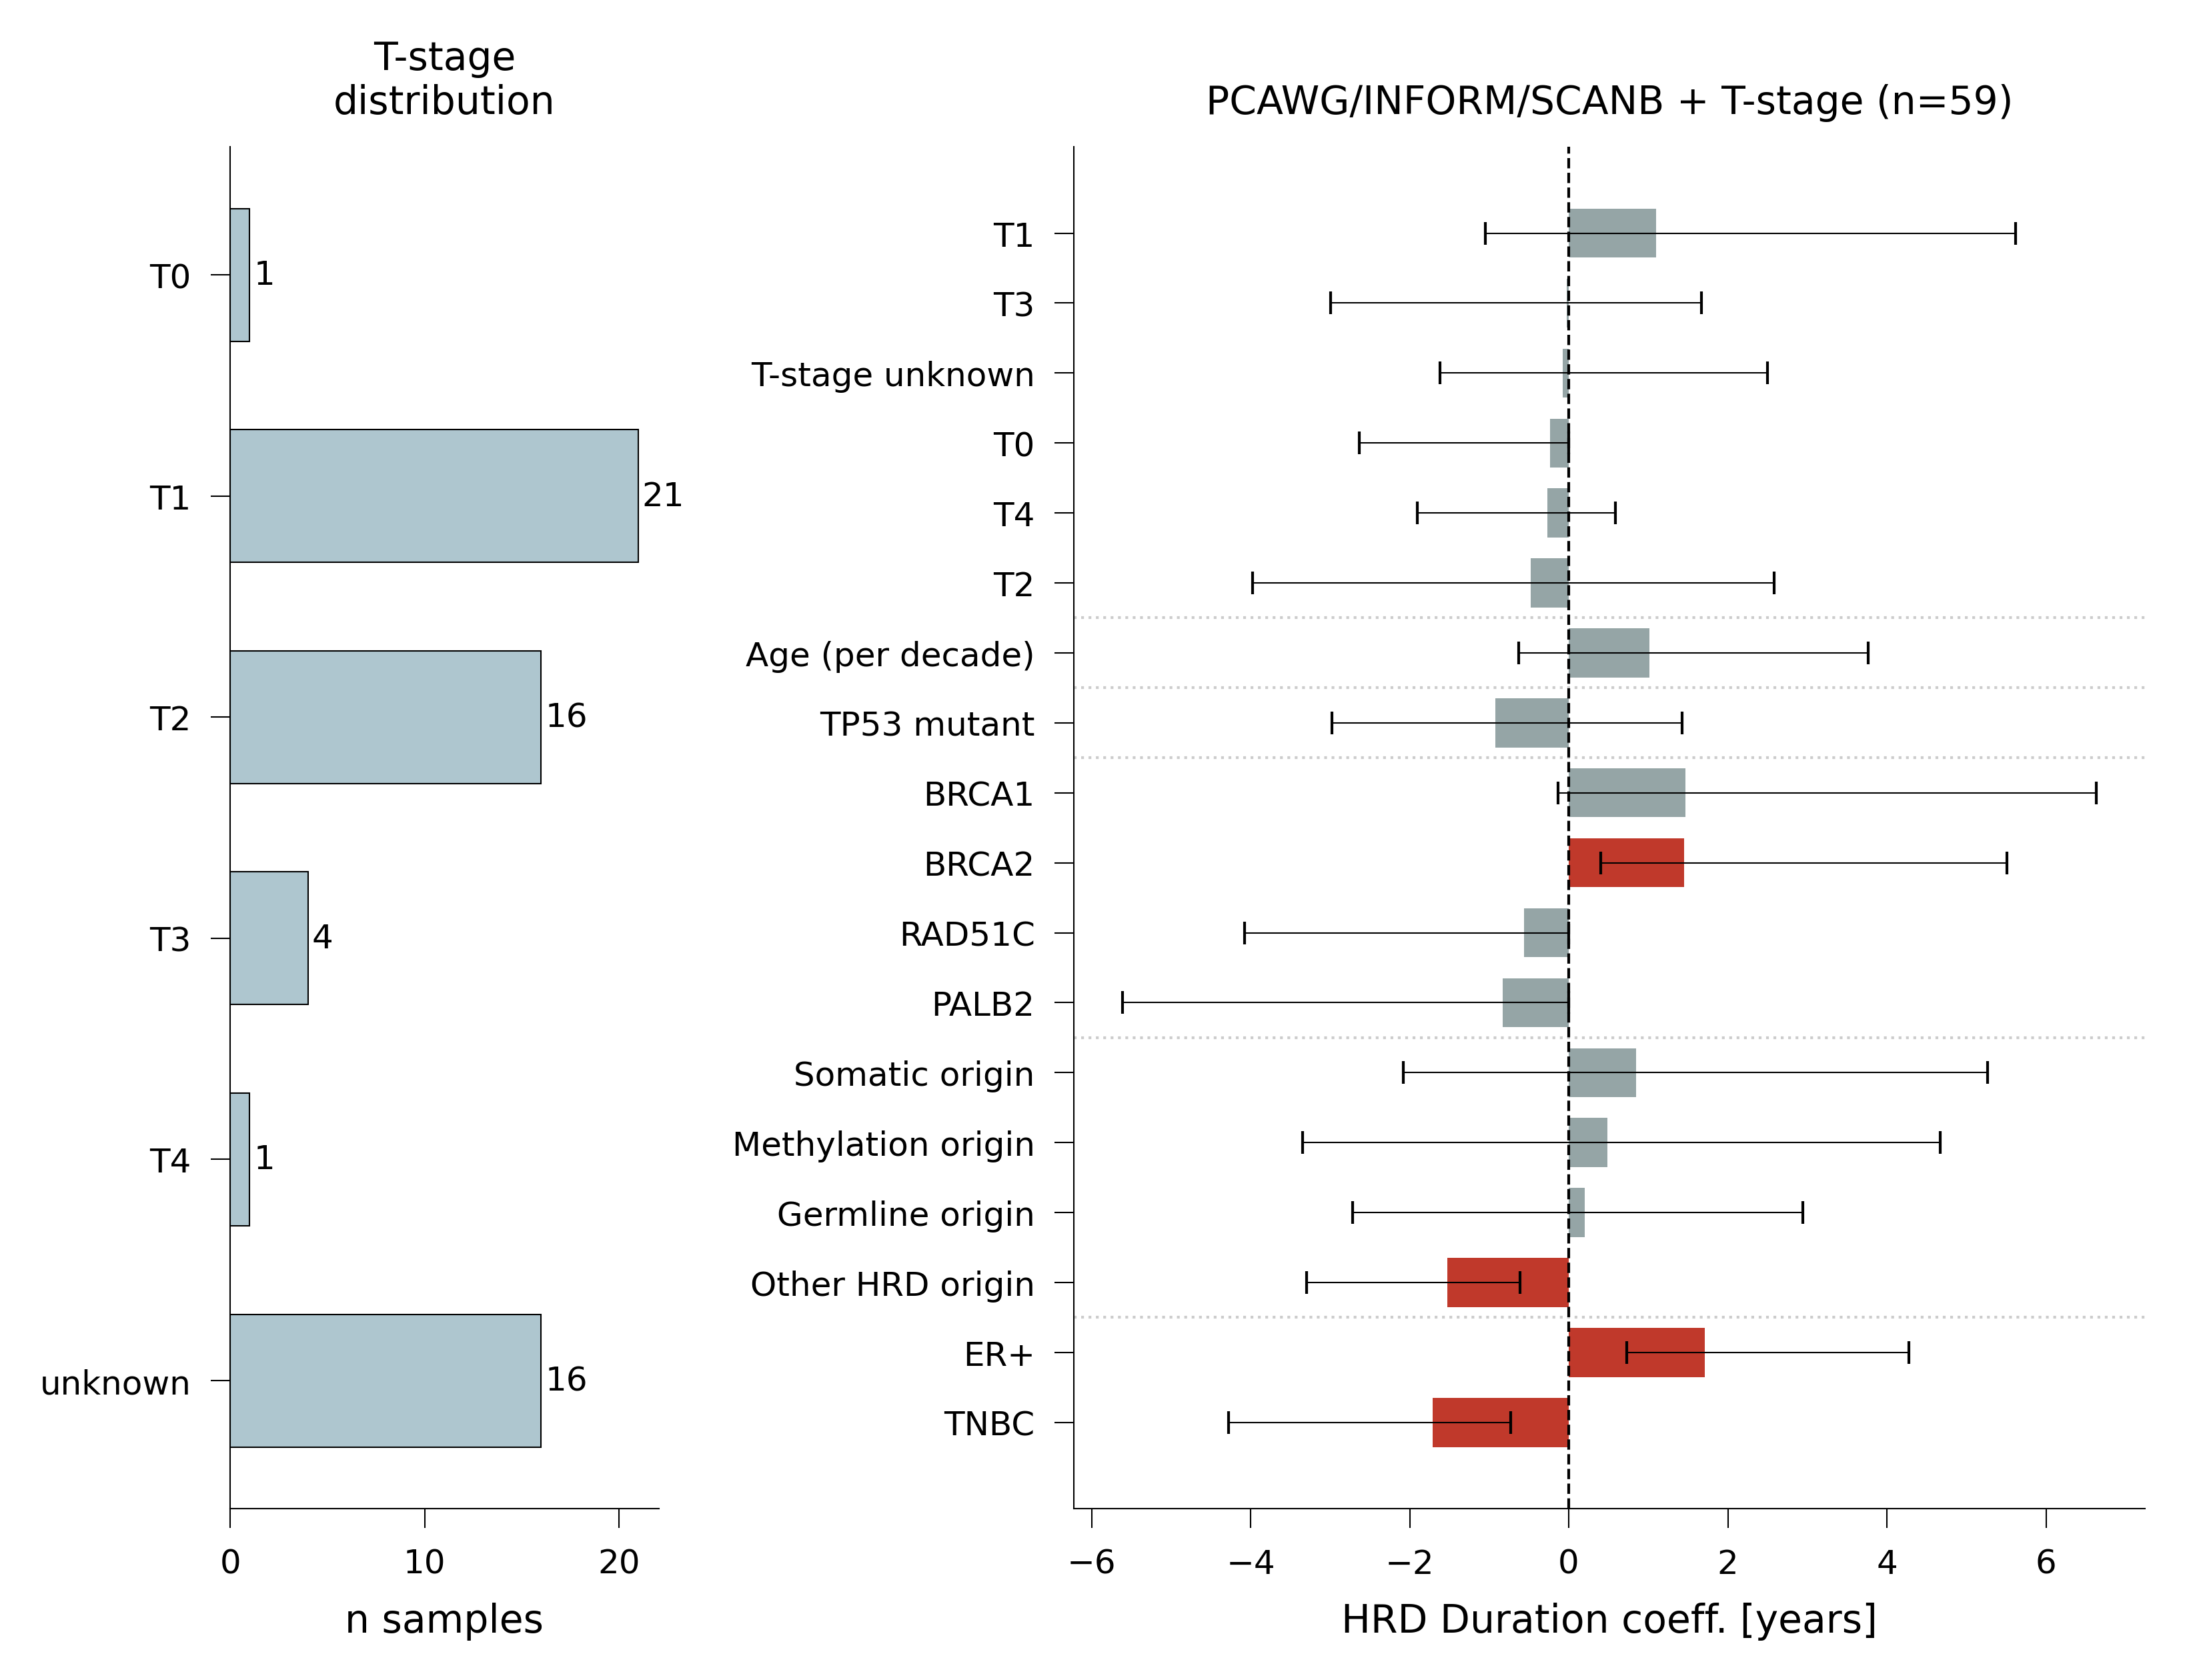

In [9]:
set_mpl_style()
CAT_COLS_T = ["type", "origin", "genotype_grp", "isTp53Mut", "T_STAGE"]
LABEL_MAP_T = {**LABEL_MAP, "T_STAGE_T0": "T0", "T_STAGE_T1": "T1", "T_STAGE_T2": "T2",
               "T_STAGE_T3": "T3", "T_STAGE_T4": "T4", "T_STAGE_unknown": "T-stage unknown"}
GROUPS_T = {**GROUPS, "T-stage": lambda f: f.startswith("T_STAGE_")}
TSTAGE_ORDER = ["T0", "T1", "T2", "T3", "T4", "unknown"]

def prep_ridge_T(d, target_col):
    d = prep_ridge(d, target_col)   # reuse base prep (origin/genotype/tp53/age)
    d["T_STAGE"] = d["T_STAGE"].fillna("unknown")
    return d.dropna(subset=[target_col] + [c for c in CAT_COLS_T + NUM_COLS if c in d.columns])

nonGEL = df[df["cohort"] != "GEL"]
dur_ridge_T = prep_ridge_T(
    nonGEL[nonGEL["type"].isin(["ER+", "TN"])][META + ["T_STAGE", "HRD_Duration_median"]]
    .rename(columns={"HRD_Duration_median": "HRD_Duration"}), "HRD_Duration")

print(f"HRD Duration (non-GEL + T_STAGE, n={len(dur_ridge_T)}):")
coef_T, r2_T, n_T = run_ridge(dur_ridge_T, "HRD_Duration", cat_cols=CAT_COLS_T)
coef_T, dividers_T = order_and_label(coef_T, groups=GROUPS_T, label_map=LABEL_MAP_T)

tstage_counts = dur_ridge_T["T_STAGE"].value_counts().reindex(TSTAGE_ORDER, fill_value=0)
tstage_pct = (tstage_counts / tstage_counts.sum() * 100).round(1)
print("\nT_STAGE distribution:")
for stage, (n, pct) in zip(tstage_counts.index, zip(tstage_counts.values, tstage_pct.values)):
    print(f"  {stage:<12s}  n={n:>2d}  ({pct:.1f}%)")

cohort_tstage = dur_ridge_T.merge(nonGEL[["sample", "cohort"]].drop_duplicates(), on="sample", how="left")
print("\nT_STAGE by cohort (%, row = cohort):")
ct = pd.crosstab(cohort_tstage["cohort"], cohort_tstage["T_STAGE"])
ct = ct.reindex(columns=[s for s in TSTAGE_ORDER if s in ct.columns])
ct_pct = (ct.div(ct.sum(axis=1), axis=0) * 100).round(1).fillna(0)
for cohort, row in ct_pct.iterrows():
    parts = "  ".join(f"{s}: {row[s]:.0f}%" for s in ct_pct.columns)
    print(f"  {cohort:<8s}  (n={int(ct.loc[cohort].sum())})  {parts}")

fig_height = max(2.5, len(coef_T) * 0.18 + 1)
fig_T, (ax_cnt, ax_reg) = plt.subplots(1, 2, figsize=(5.5, fig_height),
                                       gridspec_kw={"width_ratios": [1, 2.5]})
ax_cnt.barh(tstage_counts.index, tstage_counts.values, color="#aec6cf",
            edgecolor="black", linewidth=0.25, height=0.6)
for i, v in enumerate(tstage_counts.values): ax_cnt.text(v + 0.2, i, str(v), va="center", fontsize=6)
ax_cnt.set_xlabel("n samples", fontsize=7); ax_cnt.set_title("T-stage\ndistribution", fontsize=7)
ax_cnt.invert_yaxis()
for sp in ax_cnt.spines.values(): sp.set_linewidth(SPINE_LW)
ax_cnt.tick_params(width=SPINE_LW, labelsize=6)

ax_reg.barh(coef_T["label"], coef_T["coef"], xerr=[coef_T["coef"] - coef_T["lo"], coef_T["hi"] - coef_T["coef"]],
            color=["#c0392b" if s else "#95a5a6" for s in coef_T["sig"]], height=0.7,
            error_kw=dict(lw=0.25, capsize=2, capthick=0.5, ecolor="black"))
ax_reg.axvline(0, color="black", lw=0.5, ls="--")
for dvd in dividers_T: ax_reg.axhline(dvd, color="#cccccc", lw=0.5, ls=":", zorder=0)
ax_reg.set_xlabel("HRD Duration coeff. [years]", fontsize=7)
ax_reg.set_title(f"PCAWG/INFORM/SCANB + T-stage (n={n_T})", fontsize=7)
for sp in ax_reg.spines.values(): sp.set_linewidth(SPINE_LW)
ax_reg.tick_params(width=SPINE_LW, labelsize=6)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig5f_ridge_HRD_duration_with_Tstage.pdf", bbox_inches="tight")
plt.show()